# Image Transformation Pipeline with PyTorch
# Part 1: Fundamentals

This notebook covers the fundamentals of image transformations in PyTorch.

Topics covered:
1. What are image transformations, and what is their role in neural network training (data augmentation)
2. Image formats (PIL, NumPy, Tensor)
3. Normalization and standardization
4. Deterministic vs stochastic transformations
5. Composing transformations
6. Practical Example: Creating Train vs Validation Transforms

In [3]:
#pip install torch torchvision torchaudio

In [4]:
# ============================================================================
# SETUP AND IMPORTS
# ============================================================================

import torch
import torchvision
import torchvision.transforms as transforms
from torchvision.transforms import functional as F
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
import requests
from io import BytesIO

print(f"PyTorch version: {torch.__version__}")
print(f"Torchvision version: {torchvision.__version__}")

PyTorch version: 2.2.2
Torchvision version: 0.17.2


## 1. Introduction: What are Image Transformations?

Image transformations are operations that modify images in various ways:
- Preprocessing: Preparing images for neural networks (resize, normalize)
- Data Augmentation: Creating variations to improve model generalization
- Standardization: Converting between different formats and representations

WHY ARE THEY IMPORTANT?
1. Neural networks require consistent input sizes
2. Normalization improves training stability
3. Data augmentation prevents overfitting
4. Increases dataset diversity without collecting more data

Original image size: (481, 480)
Original image mode: RGB


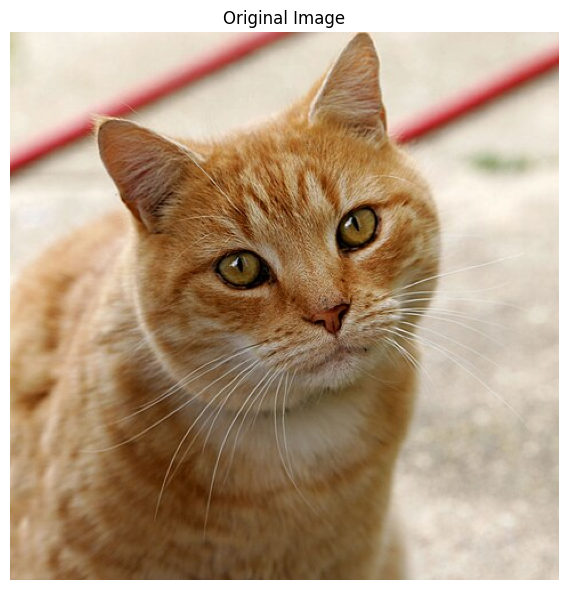

In [5]:
# Let's load a sample image
def load_sample_image():
    """Load a sample image, preferring a local copy in Week07/img."""
    local_path = Path("img/Cat03.jpg")
    if local_path.exists():
        return Image.open(local_path)

    # Fallback to downloading if the local copy is missing
    url = "https://upload.wikimedia.org/wikipedia/commons/thumb/3/3a/Cat03.jpg/481px-Cat03.jpg"
    response = requests.get(url, timeout=10)
    response.raise_for_status()
    return Image.open(BytesIO(response.content))

# Load image
original_img = load_sample_image()
print(f"Original image size: {original_img.size}")
print(f"Original image mode: {original_img.mode}")

# Display the original image
plt.figure(figsize=(8, 6))
plt.imshow(original_img)
plt.title("Original Image")
plt.axis('off')
plt.tight_layout()
plt.show()

## 2. Image Formats: PIL, NumPy, and Tensor

PyTorch works with three main image formats:

1. PIL Image (Python Imaging Library)
   - Format: (Width, Height, Channels)
   - Values: 0-255 (uint8)
   - Used for: Loading and initial processing

2. NumPy Array
   - Format: (Height, Width, Channels)
   - Values: 0-255 or 0-1 (float)
   - Used for: Numerical operations

3. PyTorch Tensor
   - Format: (Channels, Height, Width)
   - Values: Typically 0-1 (float32)
   - Used for: Neural network operations


FORMAT CONVERSIONS

1. PIL Image:
   Type: <class 'PIL.JpegImagePlugin.JpegImageFile'>
   Size: (481, 480)
   Mode: RGB

2. NumPy Array:
   Type: <class 'numpy.ndarray'>
   Shape: (480, 481, 3)
   Data type: uint8
   Value range: [0, 255]

3. PyTorch Tensor:
   Type: <class 'torch.Tensor'>
   Shape: torch.Size([3, 480, 481])
   Data type: torch.float32
   Value range: [0.0000, 1.0000]


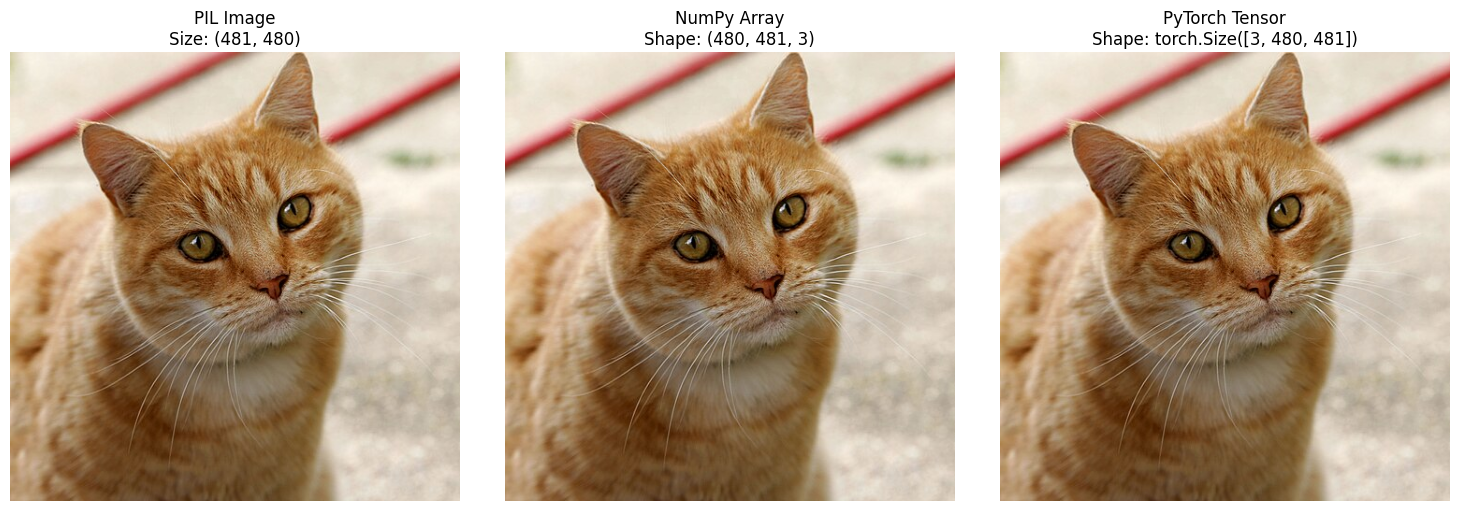

In [6]:
# Convert between formats
print("\n" + "="*60)
print("FORMAT CONVERSIONS")
print("="*60)

# 1. PIL Image (original)
print(f"\n1. PIL Image:")
print(f"   Type: {type(original_img)}")
print(f"   Size: {original_img.size}")  # (Width, Height)
print(f"   Mode: {original_img.mode}")

# 2. NumPy Array
numpy_img = np.array(original_img)
print(f"\n2. NumPy Array:")
print(f"   Type: {type(numpy_img)}")
print(f"   Shape: {numpy_img.shape}")  # (Height, Width, Channels)
print(f"   Data type: {numpy_img.dtype}")
print(f"   Value range: [{numpy_img.min()}, {numpy_img.max()}]")

# 3. PyTorch Tensor
to_tensor = transforms.ToTensor()
tensor_img = to_tensor(original_img)
print(f"\n3. PyTorch Tensor:")
print(f"   Type: {type(tensor_img)}")
print(f"   Shape: {tensor_img.shape}")  # (Channels, Height, Width)
print(f"   Data type: {tensor_img.dtype}")
print(f"   Value range: [{tensor_img.min():.4f}, {tensor_img.max():.4f}]")

# Visualize the difference in format
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(original_img)
axes[0].set_title(f"PIL Image\nSize: {original_img.size}")
axes[0].axis('off')

axes[1].imshow(numpy_img)
axes[1].set_title(f"NumPy Array\nShape: {numpy_img.shape}")
axes[1].axis('off')

# For tensor, we need to permute dimensions back to (H, W, C)
axes[2].imshow(tensor_img.permute(1, 2, 0))
axes[2].set_title(f"PyTorch Tensor\nShape: {tensor_img.shape}")
axes[2].axis('off')

plt.tight_layout()
plt.show()

## 3. Normalization and Standardization

NORMALIZATION: Scaling pixel values to a standard range

Why normalize?
- Neural networks train better with normalized inputs
- Reduces internal covariate shift
- Helps gradient flow during backpropagation

Two common normalization techniques:
- Scale to [0, 1]: ToTensor() does this automatically
- Standardize with mean/std: (x - mean) / std


NORMALIZATION EXAMPLE

Before normalization:
  Min: 0.0000, Max: 1.0000
  Mean per channel: tensor([0.6899, 0.5836, 0.4739])

After normalization (ImageNet stats):
  Min: -2.1179, Max: 2.4831
  Mean per channel: tensor([0.8946, 0.5697, 0.3016])


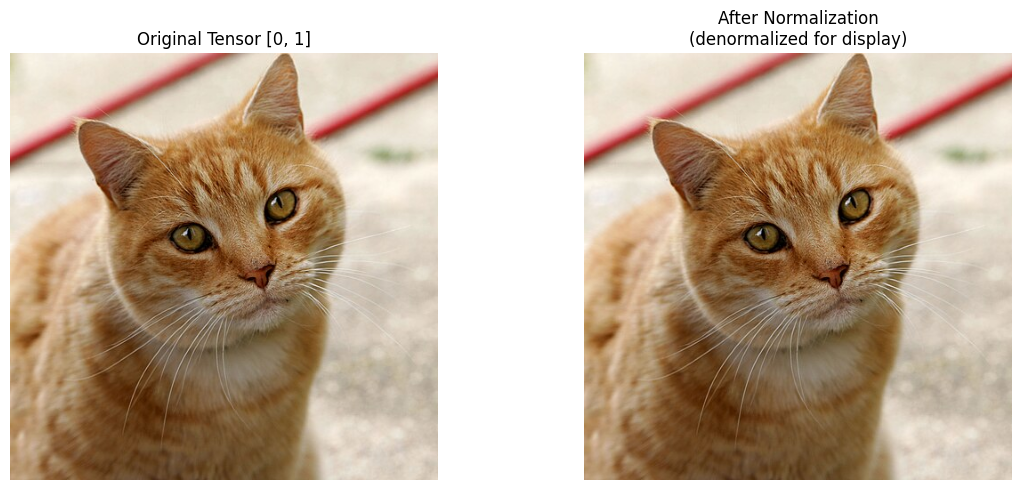

In [7]:
# Example: ImageNet normalization (standard for many pre-trained models)
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

normalize = transforms.Normalize(mean=imagenet_mean, std=imagenet_std)

# Apply normalization
tensor_normalized = normalize(tensor_img)

print("\n" + "="*60)
print("NORMALIZATION EXAMPLE")
print("="*60)
print(f"\nBefore normalization:")
print(f"  Min: {tensor_img.min():.4f}, Max: {tensor_img.max():.4f}")
print(f"  Mean per channel: {tensor_img.mean(dim=[1,2])}")

print(f"\nAfter normalization (ImageNet stats):")
print(f"  Min: {tensor_normalized.min():.4f}, Max: {tensor_normalized.max():.4f}")
print(f"  Mean per channel: {tensor_normalized.mean(dim=[1,2])}")

# Visualize normalized vs non-normalized
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(tensor_img.permute(1, 2, 0))
axes[0].set_title("Original Tensor [0, 1]")
axes[0].axis('off')

# Denormalize for visualization
denormalized = tensor_normalized.clone()
for i in range(3):
    denormalized[i] = denormalized[i] * imagenet_std[i] + imagenet_mean[i]
denormalized = torch.clamp(denormalized, 0, 1)

axes[1].imshow(denormalized.permute(1, 2, 0))
axes[1].set_title("After Normalization\n(denormalized for display)")
axes[1].axis('off')

plt.tight_layout()
plt.show()

## 4. Deterministic vs stochastic transformations

DETERMINISTIC TRANSFORMATIONS:
- Always produce the same output for the same input
- Examples: Resize, CenterCrop, ToTensor, Normalize
- Used in: Both training and validation/testing

STOCHASTIC TRANSFORMATIONS:
- Produce different outputs each time (randomness involved)
- Examples: RandomCrop, RandomHorizontalFlip, ColorJitter
- Used in: Training only (for data augmentation)


DETERMINISTIC VS STOCHASTIC TRANSFORMATIONS

Deterministic (Resize):
  Result 1 size: (224, 224)
  Result 2 size: (224, 224)
  Results identical: True

Stochastic (RandomCrop):
  Result 1 size: (200, 200)
  Result 2 size: (200, 200)
  Results identical: False


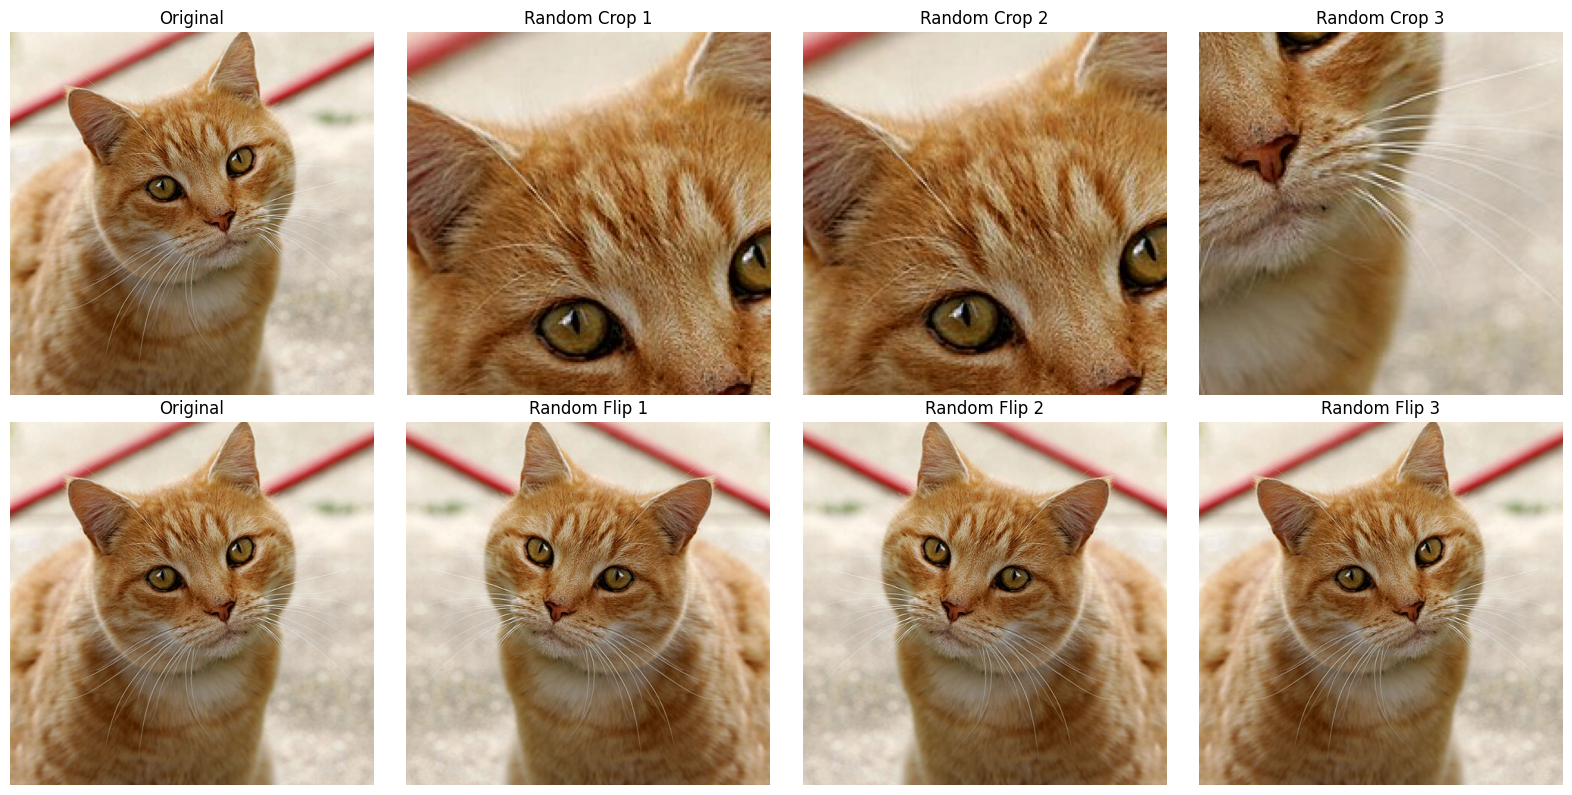

In [12]:
print("\n" + "="*60)
print("DETERMINISTIC VS STOCHASTIC TRANSFORMATIONS")
print("="*60)

# Deterministic: Resize - always gives same result
deterministic_transform = transforms.Resize((224, 224))

print("\nDeterministic (Resize):")
result1 = deterministic_transform(original_img)
result2 = deterministic_transform(original_img)
print(f"  Result 1 size: {result1.size}")
print(f"  Result 2 size: {result2.size}")
print(f"  Results identical: {np.array_equal(np.array(result1), np.array(result2))}")

# Stochastic: RandomCrop - gives different results
stochastic_transform = transforms.RandomCrop((200, 200))

print("\nStochastic (RandomCrop):")
result1 = stochastic_transform(original_img)
result2 = stochastic_transform(original_img)
print(f"  Result 1 size: {result1.size}")
print(f"  Result 2 size: {result2.size}")
print(f"  Results identical: {np.array_equal(np.array(result1), np.array(result2))}")

# Visualize stochastic transformations
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

# Original
axes[0, 0].imshow(original_img)
axes[0, 0].set_title("Original")
axes[0, 0].axis('off')

# Multiple random crops
for i in range(1, 4):
    cropped = stochastic_transform(original_img)
    axes[0, i].imshow(cropped)
    axes[0, i].set_title(f"Random Crop {i}")
    axes[0, i].axis('off')

# Random horizontal flips
flip_transform = transforms.RandomHorizontalFlip(p=1.0)
axes[1, 0].imshow(original_img)
axes[1, 0].set_title("Original")
axes[1, 0].axis('off')

for i in range(1, 4):
    # Re-initialize to get different random behavior
    flip_transform = transforms.RandomHorizontalFlip(p=0.5)
    flipped = flip_transform(original_img)
    axes[1, i].imshow(flipped)
    axes[1, i].set_title(f"Random Flip {i}")
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

## 5. Composing transformations

`transforms.Compose` allows chaining multiple transformations:
- Transformations are applied sequentially
- Order matters! (e.g., ToTensor before Normalize)
- Creates a reusable pipeline


COMPOSING TRANSFORMATIONS

Pipeline steps:
1. Resize to (256, 256)
2. CenterCrop to (224, 224)
3. Convert to Tensor
4. Normalize with ImageNet statistics

Original image size: (481, 480)
Transformed tensor shape: torch.Size([3, 224, 224])
Transformed value range: [-2.0837, 2.3060]


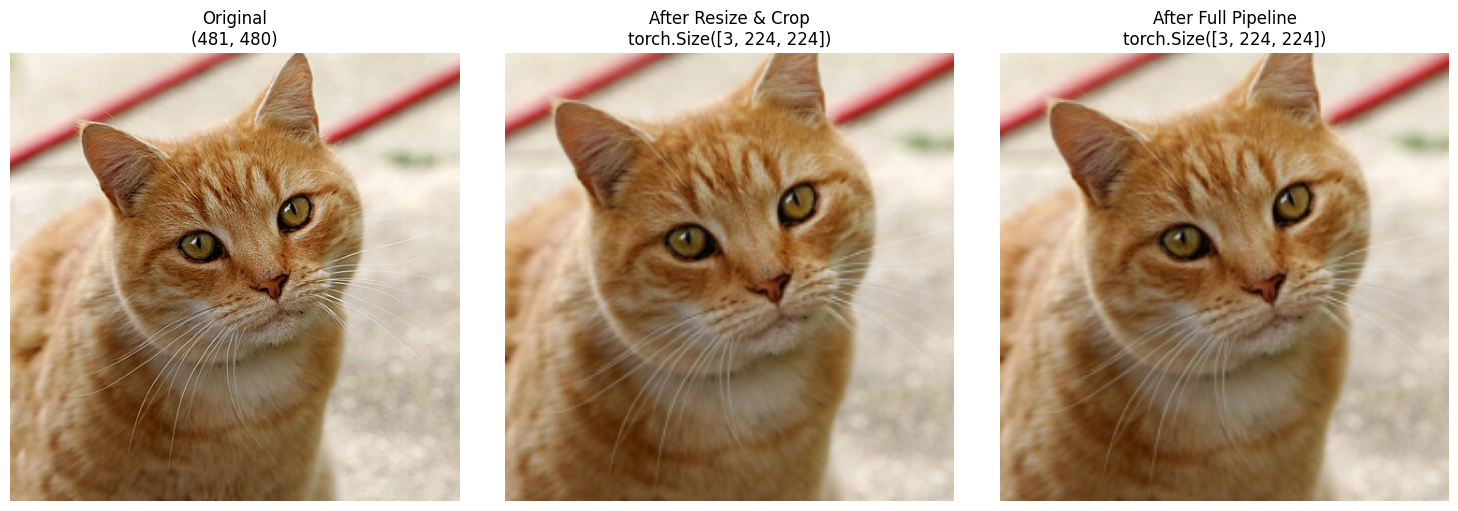

In [9]:
print("\n" + "="*60)
print("COMPOSING TRANSFORMATIONS")
print("="*60)

# Create a composed transformation pipeline
transform_pipeline = transforms.Compose([
    transforms.Resize((256, 256)),           # 1. Resize to 256x256
    transforms.CenterCrop((224, 224)),       # 2. Crop center 224x224
    transforms.ToTensor(),                   # 3. Convert to tensor [0,1]
    transforms.Normalize(                    # 4. Normalize with ImageNet stats
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("\nPipeline steps:")
print("1. Resize to (256, 256)")
print("2. CenterCrop to (224, 224)")
print("3. Convert to Tensor")
print("4. Normalize with ImageNet statistics")

# Apply the pipeline
transformed_img = transform_pipeline(original_img)

print(f"\nOriginal image size: {original_img.size}")
print(f"Transformed tensor shape: {transformed_img.shape}")
print(f"Transformed value range: [{transformed_img.min():.4f}, {transformed_img.max():.4f}]")

# Visualize the pipeline
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Original
axes[0].imshow(original_img)
axes[0].set_title(f"Original\n{original_img.size}")
axes[0].axis('off')

# After resize and crop (before normalization)
intermediate_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop((224, 224)),
    transforms.ToTensor(),
])
intermediate = intermediate_transform(original_img)
axes[1].imshow(intermediate.permute(1, 2, 0))
axes[1].set_title(f"After Resize & Crop\n{intermediate.shape}")
axes[1].axis('off')

# Final (denormalize for display)
final_denorm = transformed_img.clone()
for i in range(3):
    final_denorm[i] = final_denorm[i] * imagenet_std[i] + imagenet_mean[i]
final_denorm = torch.clamp(final_denorm, 0, 1)
axes[2].imshow(final_denorm.permute(1, 2, 0))
axes[2].set_title(f"After Full Pipeline\n{transformed_img.shape}")
axes[2].axis('off')

plt.tight_layout()
plt.show()

## 6. Practical Example: Creating Train vs Validation Transforms


PRACTICAL EXAMPLE: TRAIN VS VALIDATION TRANSFORMS

TRAIN TRANSFORMS (with augmentation):
  - RandomCrop: Different crops each time
  - RandomHorizontalFlip: 50% chance of flipping
  - Purpose: Increase data diversity

VALIDATION TRANSFORMS (no augmentation):
  - CenterCrop: Same crop every time
  - No random operations
  - Purpose: Consistent evaluation



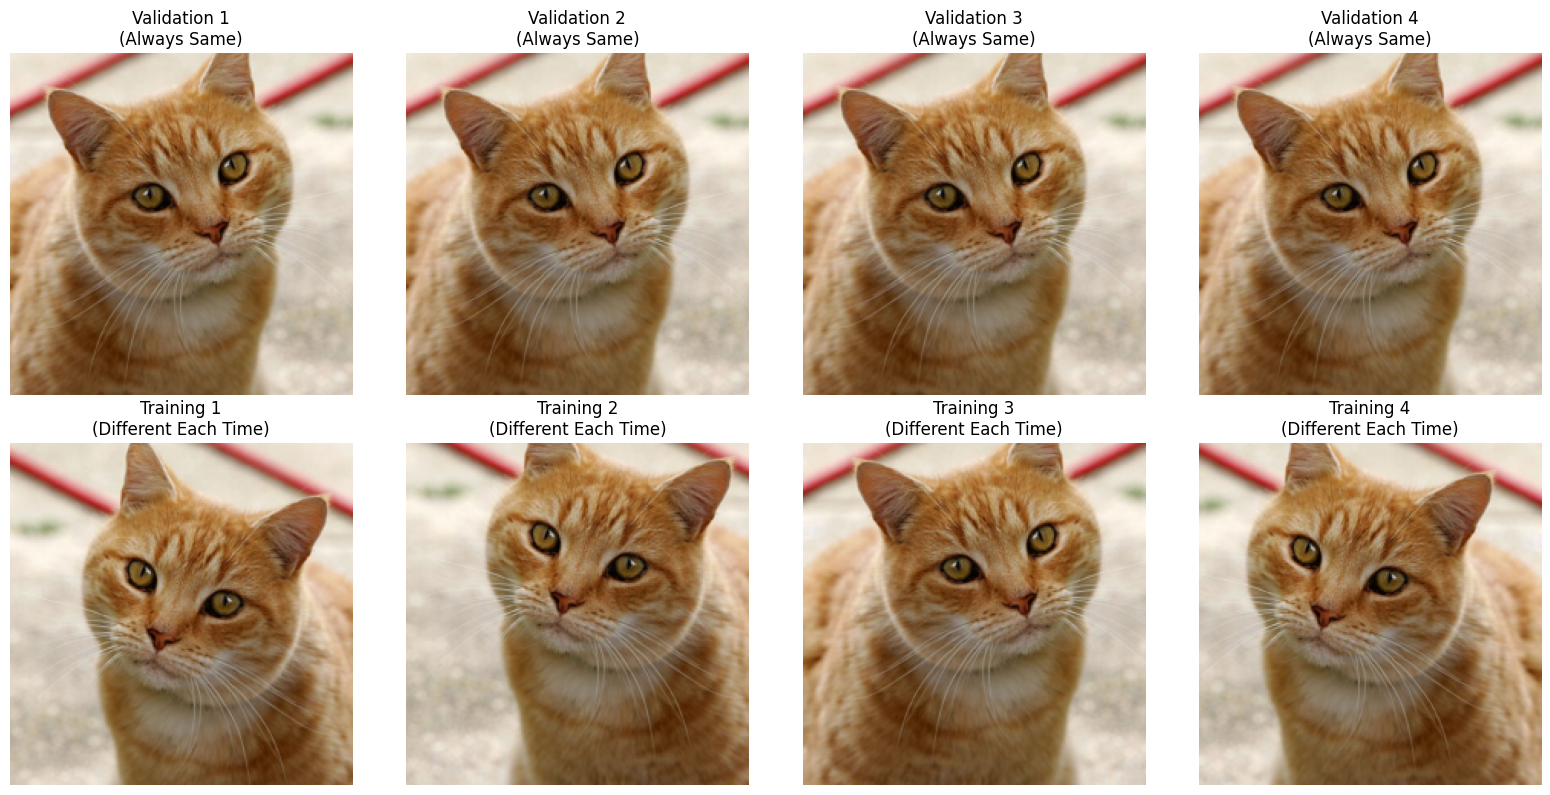

In [10]:
print("\n" + "="*60)
print("PRACTICAL EXAMPLE: TRAIN VS VALIDATION TRANSFORMS")
print("="*60)

# Training transforms (with augmentation)
train_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop((224, 224)),        # Random crop for augmentation
    transforms.RandomHorizontalFlip(p=0.5),   # Random flip
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

# Validation transforms (no augmentation)
val_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop((224, 224)),        # Center crop (deterministic)
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

print("\nTRAIN TRANSFORMS (with augmentation):")
print("  - RandomCrop: Different crops each time")
print("  - RandomHorizontalFlip: 50% chance of flipping")
print("  - Purpose: Increase data diversity\n")

print("VALIDATION TRANSFORMS (no augmentation):")
print("  - CenterCrop: Same crop every time")
print("  - No random operations")
print("  - Purpose: Consistent evaluation\n")

# Demonstrate the difference
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

# Validation (same result every time)
for i in range(4):
    val_img = val_transforms(original_img)
    # Denormalize for display
    val_denorm = val_img.clone()
    for j in range(3):
        val_denorm[j] = val_denorm[j] * imagenet_std[j] + imagenet_mean[j]
    val_denorm = torch.clamp(val_denorm, 0, 1)
    axes[0, i].imshow(val_denorm.permute(1, 2, 0))
    axes[0, i].set_title(f"Validation {i+1}\n(Always Same)")
    axes[0, i].axis('off')

# Training (different result each time)
for i in range(4):
    train_img = train_transforms(original_img)
    # Denormalize for display
    train_denorm = train_img.clone()
    for j in range(3):
        train_denorm[j] = train_denorm[j] * imagenet_std[j] + imagenet_mean[j]
    train_denorm = torch.clamp(train_denorm, 0, 1)
    axes[1, i].imshow(train_denorm.permute(1, 2, 0))
    axes[1, i].set_title(f"Training {i+1}\n(Different Each Time)")
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

# Key Takeaways

1. Image transformations are essential for:
   - Preprocessing images for neural networks
   - Data augmentation to prevent overfitting
   - Standardization across different formats

2. Three main image formats:
   - PIL: (W, H, C), values 0-255
   - NumPy: (H, W, C), values 0-255 or 0-1
   - Tensor: (C, H, W), values typically 0-1

3. Normalization improves training:
   - ToTensor() scales to [0, 1]
   - Normalize() standardizes with mean/std
   - ImageNet stats are common for transfer learning

4. Two types of transformations:
   - Deterministic: Same output every time (Resize, CenterCrop)
   - Stochastic: Random output (RandomCrop, RandomFlip)

5. Use transforms.Compose to chain operations:
   - Order matters!
   - Train transforms include augmentation
   - Validation transforms are deterministic

Next: Part 2 - Essential Transformations